sample test program to ensure everything is working first before writing out the notebook:

(A major talking point is about how i found RFECV but it only allows you to set the min number of features but not the max/how many features u want).... so I had to combine the RFE and cross val score in my own way...

In [1]:
from sklearn.datasets import load_wine
from sklearn.model_selection import cross_val_predict,cross_val_score
from sklearn.model_selection import train_test_split
from sklearn.linear_model import SGDClassifier
from sklearn.feature_selection import RFECV

data = load_wine()

X,y = data["data"],data["target"]

# patition data into training/test:
X_train,X_test,y_train,y_test = train_test_split(X,y)

# train sgdclassifier:
#sgd_clf = SGDClassifier(random_state=42).fit(X_train, y_train)

# cross validation:
#y_pred = cross_val_predict(sgd_clf,X_train,y_train,cv=5)

# for choosing the features i.e. feature selection im thinking about either calculating like the scores for the model then 
# simply using like a for loop to compare and pull out two of the highest ones? Maybe that's what the task wants when it
# says Select the 2 most higher-performing features based upon cross-validation carried out on the training dataset.
# or im thinking maybe using RFE would be suitable which i picked up from this article:
# https://medium.com/@shradhdha.bhalodia/cross-validation-feature-selection-and-model-evaluation-with-scikit-learn-edc0e414c74e
# Even more interesting I came to this:
# https://www.geeksforgeeks.org/machine-learning/recursive-feature-elimination-with-cross-validation-in-scikit-learn/

#scores = cross_val_score(sgd_clf,X,y,cv=5)


#print(scores)

estimator = SGDClassifier(random_state=42)
selector = RFECV(estimator,step=1,cv=5)
selector = selector.fit(X, y)
print(selector.support_)

[ True False False False False False  True False False  True False False
 False]


In [2]:
from sklearn.datasets import load_wine
from sklearn.model_selection import cross_val_predict,cross_val_score
from sklearn.model_selection import train_test_split
from sklearn.linear_model import SGDClassifier
from sklearn.feature_selection import RFE

data = load_wine()

X,y = data["data"],data["target"]

# patition data into training/test:
X_train,X_test,y_train,y_test = train_test_split(X,y)

# train sgdclassifier:
#sgd_clf = SGDClassifier(random_state=42).fit(X_train, y_train)

# cross validation:
#y_pred = cross_val_predict(sgd_clf,X_train,y_train,cv=5)

# for choosing the features i.e. feature selection im thinking about either calculating like the scores for the model then 
# simply using like a for loop to compare and pull out two of the highest ones? Maybe that's what the task wants when it
# says Select the 2 most higher-performing features based upon cross-validation carried out on the training dataset.
# or im thinking maybe using RFE would be suitable which i picked up from this article:
# https://medium.com/@shradhdha.bhalodia/cross-validation-feature-selection-and-model-evaluation-with-scikit-learn-edc0e414c74e
# Even more interesting I came to this:
# https://www.geeksforgeeks.org/machine-learning/recursive-feature-elimination-with-cross-validation-in-scikit-learn/

#scores = cross_val_score(sgd_clf,X,y,cv=5)


#print(scores)

estimator = SGDClassifier(random_state=0)
selector = RFE(estimator,n_features_to_select=2)
scores = cross_val_score(selector, X_train, y_train, cv=5)
selector.fit(X_train,y_train)
print("Top performing features within feature selection using CV: %d" % selector.n_features_)

print(selector.ranking_)



Top performing features within feature selection using CV: 2
[ 4  6 10  1  2  8  5 12  9  1 11  7  3]


I just realised I've been approaching this in the wrong way.... RFE/RFECV is not good enough because we want 2 most higher performing features, so we will literally have to pick out all possible combinations of 2 features, 13 choose 2 so 78 total combinations and pick the one that scores the highest with the confusion matrix, f1 scores etc.... Once I follow it like that it should be quite easy to get this part done...

Best feature 1: 11 which is also labelled: od280/od315_of_diluted_wines
Best feature 2: 12 which is also labelled: proline
Best mean F1: 0.9028337562820322
Confusion Matrix:
 [[16  0  0]
 [ 1 18  2]
 [ 1  0  7]]
Recall Score : [1.         0.85714286 0.875     ]
Precision Score : [0.88888889 1.         0.77777778]
F1 score: [0.94117647 0.92307692 0.82352941]
{0: 0.997844827586207, 1: 0.9781746031746031, 2: 0.9527027027027026}


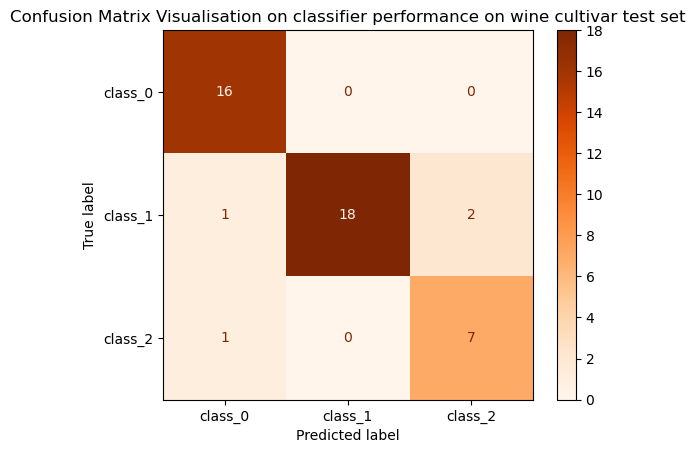

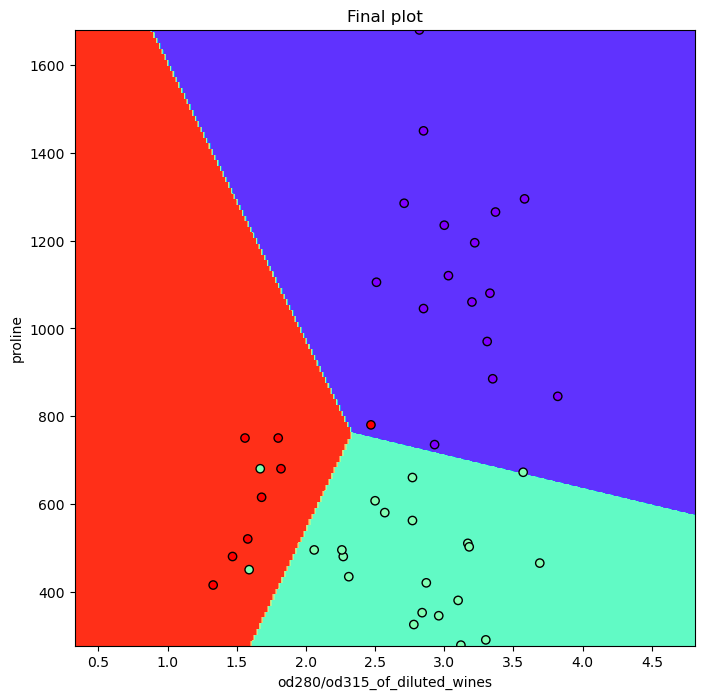

In [2]:
from sklearn.datasets import load_wine
from sklearn.linear_model import SGDClassifier
from sklearn.model_selection import train_test_split,cross_val_predict
from sklearn.metrics import confusion_matrix,f1_score,recall_score,precision_score,roc_curve,auc,ConfusionMatrixDisplay
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
import numpy as np

data = load_wine()

X,y = data["data"],data["target"]

# partition data into training/test: Step 1
X_train,X_test,y_train,y_test = train_test_split(X,y,random_state=0)

# feature selection (highest performing features based upon cross-validation on training set) STep 2
best_mean_f1 = 0
best_feature1 = 0
best_feature2 = 0

for feature1 in range(13):
    for feature2 in range(13):
        
        if feature1 == feature2:
            continue
        
        idx = [feature1,feature2]
        
        sgd_clf = Pipeline([("scaler",StandardScaler()),("sgd",SGDClassifier(random_state=0))])
        sgd_clf.fit(X_train[:,idx],y_train)
        
        y_pred = cross_val_predict(sgd_clf,X_train[:,idx],y_train,cv=5)
        
        curr_mean_f1 = np.mean(f1_score(y_train,y_pred,average=None))
        
        if curr_mean_f1 > best_mean_f1:
            best_mean_f1 = curr_mean_f1
            best_feature1 = feature1
            best_feature2 = feature2

print("Best feature 1: %d " % best_feature1 + "which is also labelled: %s" % data.feature_names[best_feature1])
print("Best feature 2: %d " % best_feature2 + "which is also labelled: %s" % data.feature_names[best_feature2])
print(f"Best mean F1: {best_mean_f1}")

# Step 3
best_features_idx = [best_feature1,best_feature2]

sgd_clf = Pipeline([("scaler",StandardScaler()),("sgd",SGDClassifier(random_state=0))])
sgd_clf.fit(X_train[:,best_features_idx],y_train)

y_pred = sgd_clf.predict(X_test[:,best_features_idx])

# & Make sure we are visualising this confusion matrix.... 
conf_matrix = confusion_matrix(y_test,y_pred)

print(f"Confusion Matrix:\n {conf_matrix}")

# These next sequence of steps are all taken to help us visualise the confusion matrix:
fig,ax = plt.subplots()
ConfusionMatrixDisplay.from_estimator(sgd_clf,X_test[:,best_features_idx],y_test,display_labels=data.target_names,ax=ax,cmap=plt.cm.Oranges)
ax.set_title("Confusion Matrix Visualisation on classifier performance on wine cultivar test set")

recall = recall_score(y_test,y_pred,average=None)
precision = precision_score(y_test,y_pred,average=None)
f1 = f1_score(y_test,y_pred,average=None)

print(f"Recall Score : {recall}" )
print(f"Precision Score : {precision}" )  
print(f"F1 score: {f1}" )      

y_scores = sgd_clf.decision_function(X_test[:,best_features_idx])

y_test_bin = label_binarize(y_test,classes=[0,1,2])
false_positive_rate = dict()
true_positive_rate = dict()
roc_auc = dict()

for i in range(3):
    false_positive_rate[i],true_positive_rate[i],_ = roc_curve(y_test_bin[:,i],y_scores[:,i])
    roc_auc[i] = auc(false_positive_rate[i],true_positive_rate[i])
# & Also make sure we plot these roc curves for each of the classes along with the AUC..
# & how we should interpret the results
print(roc_auc)


X_train_selected = X_train[:,best_features_idx]
X_test_selected = X_test[:,best_features_idx]

# creating the mesh to plot in:
x_min, x_max = X_test[:,best_feature1].min() - 1, X_test[:,best_feature1].max() + 1
y_min, y_max = X_test[:,best_feature2].min() - 1, X_test[:,best_feature2].max() + 1

xx,yy = np.meshgrid(np.arange(x_min,x_max,0.02),np.arange(y_min,y_max,0.2))

grid_predictions = sgd_clf.predict(np.c_[xx.ravel(),yy.ravel()])

# putting result into colour shape:
grid_predictions = grid_predictions.reshape(xx.shape)

fig, ax = plt.subplots(figsize=(8,8))

ax.contourf(xx,yy,grid_predictions,cmap="rainbow")

ax.scatter(X_test_selected[:,0],X_test_selected[:,1],c=y_test,cmap="rainbow",edgecolor="black")

plt.xlabel(data.feature_names[best_feature1])
plt.ylabel(data.feature_names[best_feature2])
plt.title("Final plot")

plt.show()

